# Highlighting

When a figure carries many series, the story is usually about one of them: one model run among its competitors, one cohort inside the population, one trend over raw observations. The `emphasis` parameter expresses that relationship directly — per chart, not via global styling:

- `"background"` mutes a series: it takes the active theme's `muted_color` at `muted_alpha`, gets thinner strokes, drops behind the other series, claims no color-cycle slot, and is excluded from the legend.
- `"highlight"` bolds a series and brings it to the front of the data layers (never above axes or reference lines). It keeps its theme-assigned color and legend entry.
- Leaving it unset (`None`) draws the series exactly as before.

`emphasis` is accepted by `LineChart`, `BarChart`, `ScatterChart`, `Histogram`, `ParallelCoords` (per data row), and `BoxPlot` (per box label), and as a per-figure `"emphasis"` option in `Panel`. Because muting derives from the theme's `muted_color`/`muted_alpha` attributes, background series harmonize with whatever theme is active.

In [1]:
import numpy as np

from datachart.charts import (
    BoxPlot,
    Histogram,
    LineChart,
    ParallelCoords,
    ScatterChart,
)
from datachart.utils import Panel
from datachart.config import config
from datachart.constants import THEME

## One Walk Among Many

The `emphasis` list aligns with the charts, like `style` and `subtitle`. Background walks fade into context; the highlighted walk keeps its cycle color and doubles its line width. Only emphasized-or-unset series appear in the legend.

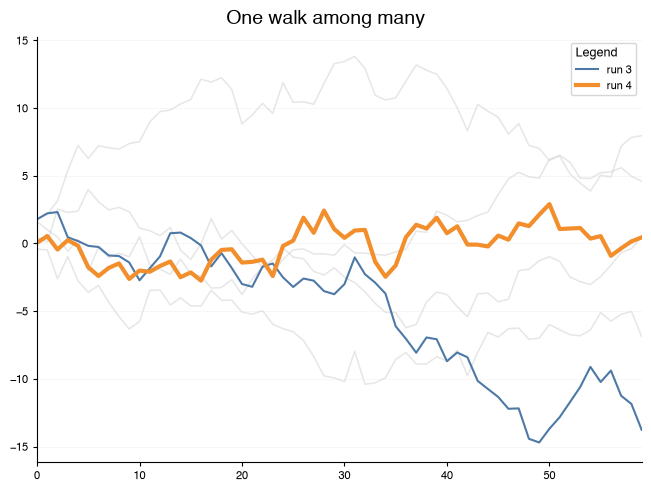

In [2]:
def walk(seed, n=60):
    rng = np.random.RandomState(seed)
    return [{"x": i, "y": float(v)} for i, v in enumerate(np.cumsum(rng.randn(n)))]

walks = [walk(seed) for seed in range(6)]

figure = LineChart(
    data=walks,
    subtitle=[f"run {i}" for i in range(6)],
    emphasis=["background", "background", "background", None, "highlight", "background"],
    show_legend=True,
    title="One walk among many",
)
figure.show()

## The Same Figure Under Another Theme

Muting is defined by the theme's `muted_color` and `muted_alpha` attributes, so the same chart code stays harmonious under any theme — no hand-picked greys.

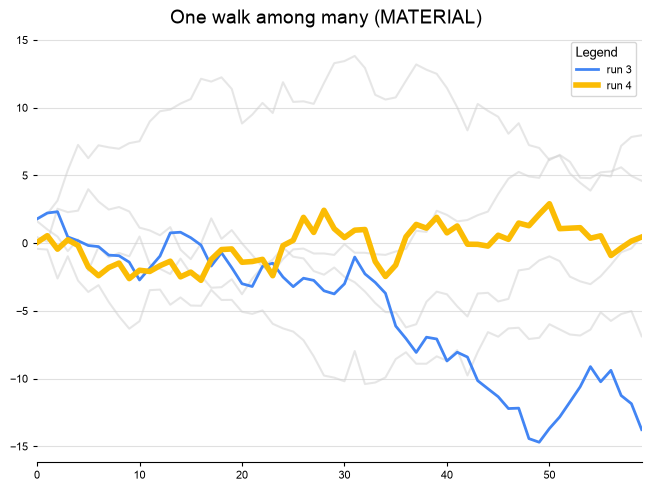

In [3]:
config.set_theme(THEME.MATERIAL)

figure = LineChart(
    data=walks,
    subtitle=[f"run {i}" for i in range(6)],
    emphasis=["background", "background", "background", None, "highlight", "background"],
    show_legend=True,
    title="One walk among many (MATERIAL)",
)
figure.show()

config.reset_config()

## A Cohort Inside a Scatter Cloud

A highlighted scatter series keeps its marker size but gains a contrasting edge; the background cloud recedes without disappearing.

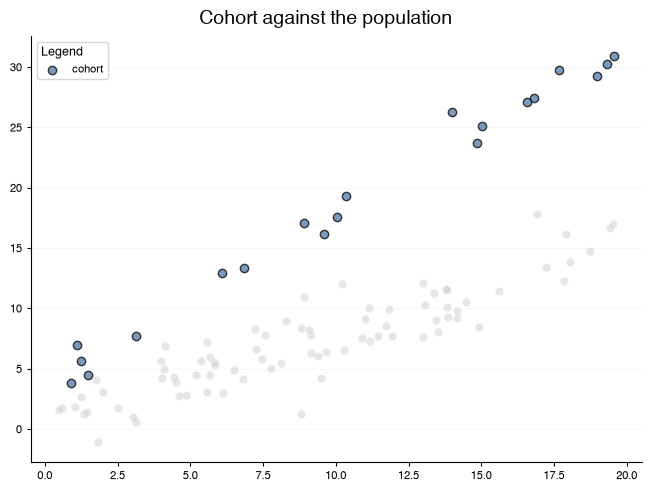

In [4]:
rng = np.random.RandomState(3)
population = [
    {"x": float(x), "y": float(x * 0.8 + rng.randn() * 2)}
    for x in rng.rand(80) * 20
]
cohort = [
    {"x": float(x), "y": float(x * 1.4 + 4 + rng.randn())}
    for x in rng.rand(20) * 20
]

figure = ScatterChart(
    data=[population, cohort],
    subtitle=["population", "cohort"],
    emphasis=["background", "highlight"],
    show_legend=True,
    title="Cohort against the population",
)
figure.show()

## Best Runs in Parallel Coordinates

For `ParallelCoords` the `emphasis` list aligns with the data **rows**. Highlighted rows come forward but stay below the axis furniture, so the axis lines and tick labels remain readable.

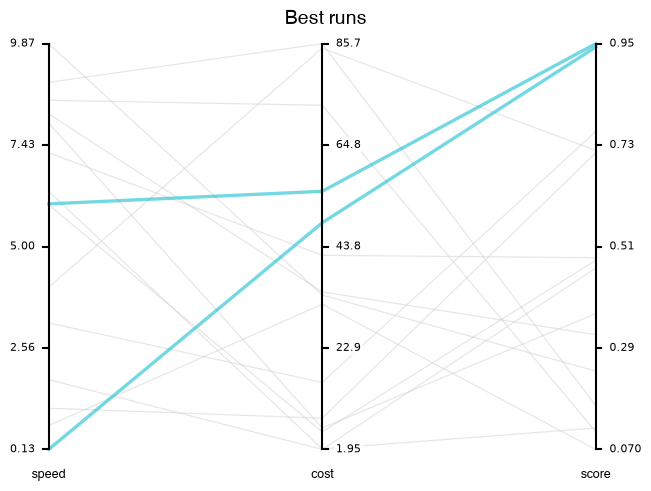

In [5]:
rng = np.random.RandomState(11)
runs = [
    {
        "speed": float(rng.rand() * 10),
        "cost": float(rng.rand() * 100),
        "score": float(rng.rand()),
    }
    for _ in range(15)
]
best = sorted(range(len(runs)), key=lambda i: runs[i]["score"])[-2:]

figure = ParallelCoords(
    data=runs,
    dimensions=["speed", "cost", "score"],
    emphasis=["highlight" if i in best else "background" for i in range(len(runs))],
    title="Best runs",
)
figure.show()

## A Cohort Against a Reference Distribution

Multi-series histograms normally draw stacked. Stacking a muted background is meaningless, so as soon as any series carries an emphasis role the histograms draw individually overlaid — on shared bins, with the background distribution behind the cohort.

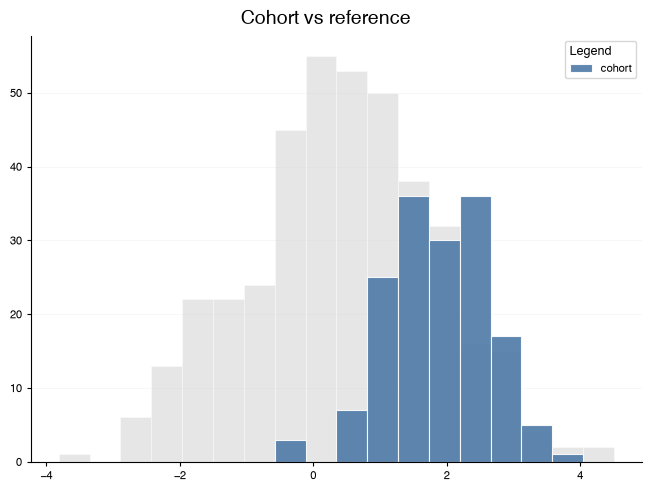

In [6]:
rng = np.random.RandomState(7)
reference = [{"x": float(v)} for v in rng.randn(400) * 1.4 + 0.5]
cohort = [{"x": float(v)} for v in rng.randn(160) * 0.8 + 2.0]

figure = Histogram(
    data=[reference, cohort],
    subtitle=["reference", "cohort"],
    emphasis=["background", None],
    num_bins=18,
    show_legend=True,
    title="Cohort vs reference",
)
figure.show()

## Per-Label Emphasis in a Box Plot

Box charts never overlay, so their `emphasis` aligns with the box **labels** of one call. Whiskers, caps, medians, and outliers mute together with their box; a highlighted box gets bolder edges and a bolder median.

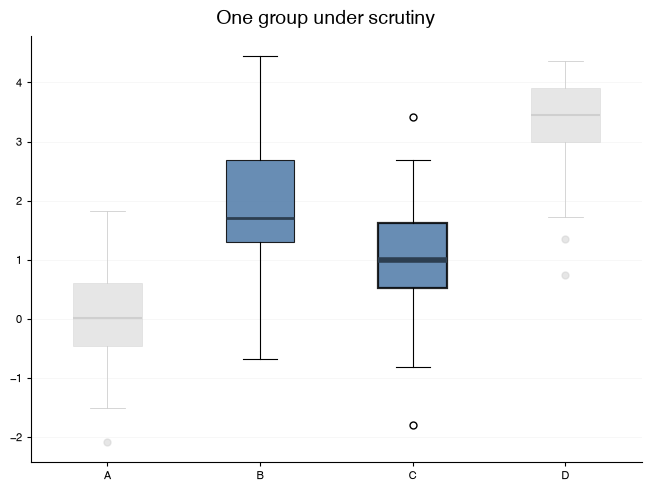

In [7]:
rng = np.random.RandomState(9)
data = [
    {"label": lab, "value": float(v + off)}
    for lab, off in [("A", 0.0), ("B", 2.0), ("C", 1.0), ("D", 3.0)]
    for v in rng.randn(30)
]

figure = BoxPlot(
    data=data,
    emphasis=["background", None, "highlight", "background"],
    title="One group under scrutiny",
)
figure.show()

## Composing Context and Focus with Panel

`Panel` accepts a per-figure `"emphasis"` option next to `y_axis`, `z_order`, and `legend_label`. The role applies to every layer of that figure — here the raw observations become context under a highlighted trend. The muted figure drops out of the legend automatically.

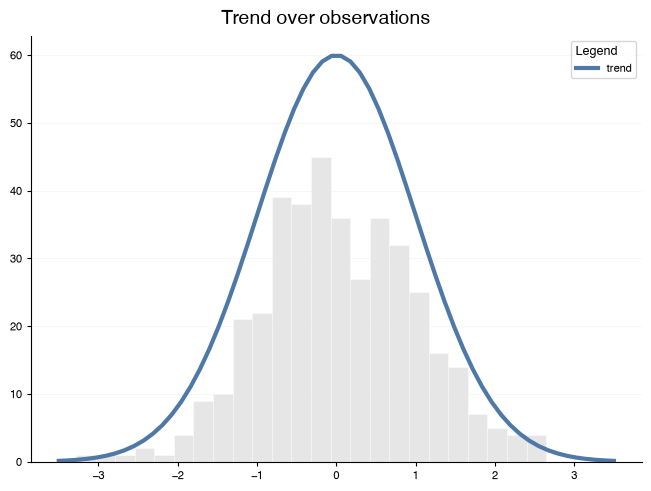

In [8]:
rng = np.random.RandomState(5)
observations = [{"x": float(v)} for v in rng.randn(400)]
xs = np.linspace(-3.5, 3.5, 60)
trend = [{"x": float(x), "y": float(60 * np.exp(-x * x / 2))} for x in xs]

hist_fig = Histogram(data=observations, num_bins=24, subtitle="observations")
trend_fig = LineChart(data=trend, subtitle="trend")

figure = Panel(
    [
        {"figure": hist_fig, "emphasis": "background"},
        {"figure": trend_fig, "emphasis": "highlight"},
    ],
    title="Trend over observations",
    show_legend=True,
)
figure.show()

Composed parallel-coordinates figures also normalize against shared per-dimension ranges inside a `Panel`, so a muted context figure and a highlighted runs figure line up on the same axis scales.